# Tahoe Transfer From Narrowed L1000

This notebook visualizes cross-dataset transfer **from the Tahoe-filtered L1000 exports** in `data/l1000_narrowed_to_tahoe` into Tahoe. It follows the stricter framing from the project note:

- first measure when transfer is valid,
- then summarize where concordance is stable,
- and only treat donor L1000 signatures as useful when those transferability signals are present.

The notebook therefore builds a compact **concordance atlas** rather than a predictor. It uses matched perturbations defined by:

- same `cell_type`
- same `pubchem_cid`
- nearest available dose/time in the donor L1000 dataset

The main visual outputs are:

- donor availability by Tahoe cell line
- per-match concordance distributions
- donor-dataset and donor-cell-line transfer heatmaps
- top transferable compounds
- one example matched-signature scatter
- a simple "portable genes" summary based on strong-response sign agreement

In [1]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse, stats

from op3_analysis.retrieval.config import DEFAULT_DATASET_PATHS
from op3_analysis.retrieval.parallel import build_truth_matches_and_tasks, write_pair_match_anndatas

warnings.filterwarnings("ignore", message="Observation names are not unique")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
FILTERED_DIR = PROJECT_ROOT / "data" / "l1000_narrowed_to_tahoe"
OUTPUT_DIR = PROJECT_ROOT / "results" / "l1000_to_tahoe_transfer"
CACHE_DIR = OUTPUT_DIR / "cache"
PAIR_PREFIX = "tahoe_transfer"
REPRESENTATION = "logFC"
TOP_K = 50
TAHOE_PATH = DEFAULT_DATASET_PATHS["tahoe"]

if not FILTERED_DIR.exists():
    raise FileNotFoundError(f"Filtered L1000 directory does not exist: {FILTERED_DIR}")

l1000_paths = {path.stem: path for path in sorted(FILTERED_DIR.glob("*.h5ad"))}
if not l1000_paths:
    raise FileNotFoundError(f"No filtered L1000 .h5ad files found under {FILTERED_DIR}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

filter_summary = pd.read_csv(FILTERED_DIR / "filter_summary.csv")
kept_lines = filter_summary.loc[
    filter_summary["kept"] & filter_summary["dataset_name"].isin(l1000_paths)
].copy()
dataset_paths = {"tahoe": TAHOE_PATH, **l1000_paths}

display(pd.DataFrame({"dataset_name": list(l1000_paths.keys()), "path": [str(path) for path in l1000_paths.values()]}))
display(
    kept_lines.groupby("dataset_name")
    .agg(
        kept_cell_lines=("cell_type", "nunique"),
        median_shared_compounds=("n_shared_compounds", "median"),
        max_shared_compounds=("n_shared_compounds", "max"),
        total_shared_rows=("n_shared_rows", "sum"),
    )
    .sort_index()
)


,dataset_name,path
0,l1000_phase1,/ictstr01/groups/ml01/workspace/artur.szalata/...
1,l1000_phase2,/ictstr01/groups/ml01/workspace/artur.szalata/...


,kept_cell_lines,median_shared_compounds,max_shared_compounds,total_shared_rows
dataset_name,,,,
l1000_phase1,62,18.0,109,3921
l1000_phase2,21,20.0,112,7283


## Build Tahoe↔L1000 Matched Perturbations

The notebook reuses the repository's existing retrieval precompute logic so that donor matching stays consistent with the rest of the codebase. A match means:

- same `cell_type`
- same `pubchem_cid`
- donor row chosen by nearest `pert_time_h` and nearest `pert_dose_uM`

This avoids introducing a notebook-only matching rule.

In [3]:
truth_cache = CACHE_DIR / "tahoe_l1000_truth_matches.csv"
truth_summary_cache = CACHE_DIR / "tahoe_l1000_truth_summary.csv"

if truth_cache.exists() and truth_summary_cache.exists():
    truth_df = pd.read_csv(truth_cache)
    truth_summary_df = pd.read_csv(truth_summary_cache)
else:
    truth_df, truth_summary_df, _ = build_truth_matches_and_tasks(
        dataset_paths=dataset_paths,
        query_datasets=["tahoe"],
        db_datasets=list(l1000_paths.keys()),
        include_self_dataset=False,
        split_by_cell_type=True,
        verbose=False,
    )
    truth_df.to_csv(truth_cache, index=False)
    truth_summary_df.to_csv(truth_summary_cache, index=False)

pair_dir = CACHE_DIR / f"{PAIR_PREFIX}_pair_matches"

def discover_pair_paths() -> dict[str, Path]:
    discovered = {}
    if not pair_dir.exists():
        return discovered
    for path in sorted(pair_dir.glob("*_matches.h5ad")):
        pair_name = path.stem.removesuffix("_matches")
        left, right = pair_name.split("__", 1)
        donor_dataset = right if left == "tahoe" else left
        if donor_dataset != "tahoe":
            discovered[donor_dataset] = path
    return discovered

pair_paths = discover_pair_paths()
expected_donors = set(l1000_paths)
if set(pair_paths) != expected_donors:
    write_pair_match_anndatas(
        truth_df=truth_df,
        dataset_paths=dataset_paths,
        output_dir=CACHE_DIR,
        output_prefix=PAIR_PREFIX,
        verbose=False,
    )
    pair_paths = discover_pair_paths()

if not pair_paths:
    raise RuntimeError(f"No Tahoe/L1000 pair AnnData files were produced under {pair_dir}")

display(
    truth_summary_df.sort_values(["db_dataset", "n_truth_queries"], ascending=[True, False]).reset_index(drop=True)
)
print(f"Total truth matches: {len(truth_df):,}")
print(pair_paths)


,query_dataset,db_dataset,query_cell_type,n_query_obs,n_shared_pubchem_cids,n_truth_queries,n_genes_gt_pair
0,tahoe,l1000_phase1,CVCL_0023,1132,96,288,975.0
1,tahoe,l1000_phase1,CVCL_0320,1133,95,285,975.0
2,tahoe,l1000_phase1,CVCL_0399,1134,19,57,977.0
3,tahoe,l1000_phase1,CVCL_0504,1131,18,54,975.0
4,tahoe,l1000_phase1,CVCL_0546,1134,18,54,978.0
5,tahoe,l1000_phase1,CVCL_0332,1132,11,36,974.0
6,tahoe,l1000_phase2,CVCL_0320,1133,110,333,975.0
7,tahoe,l1000_phase2,CVCL_0023,1132,24,75,975.0


Total truth matches: 1,182
{'l1000_phase1': PosixPath('/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/l1000_to_tahoe_transfer/cache/tahoe_transfer_pair_matches/l1000_phase1__tahoe_matches.h5ad'), 'l1000_phase2': PosixPath('/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/l1000_to_tahoe_transfer/cache/tahoe_transfer_pair_matches/l1000_phase2__tahoe_matches.h5ad')}


In [4]:
def dense_layer(adata: ad.AnnData, layer: str) -> np.ndarray:
    matrix = adata.layers[layer]
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)


def topk_signed_overlap(x: np.ndarray, y: np.ndarray, k: int = 50) -> float:
    k = int(min(k, x.size, y.size))
    if k < 1:
        return float("nan")
    up_x = set(np.argpartition(-x, k - 1)[:k].tolist())
    up_y = set(np.argpartition(-y, k - 1)[:k].tolist())
    down_x = set(np.argpartition(x, k - 1)[:k].tolist())
    down_y = set(np.argpartition(y, k - 1)[:k].tolist())
    return 0.5 * (len(up_x & up_y) / k + len(down_x & down_y) / k)


def expanded_match_obs(pair_adata: ad.AnnData) -> pd.DataFrame:
    match_col = next((col for col in pair_adata.uns.get("match_id_columns", []) if col.startswith("tahoe_")), None)
    if match_col is None:
        raise ValueError(f"Could not find Tahoe match-id column in {pair_adata.uns.get('match_id_columns')}")

    obs = pair_adata.obs.copy().reset_index().rename(columns={"index": "pair_obs_name"})
    obs["row_idx"] = np.arange(pair_adata.n_obs)
    rows = []
    for record in obs.to_dict("records"):
        raw_match_ids = record.get(match_col, "")
        if pd.isna(raw_match_ids) or not str(raw_match_ids).strip():
            continue
        for match_id in [part for part in str(raw_match_ids).split(",") if part]:
            rows.append(
                {
                    "match_id": match_id,
                    "row_idx": int(record["row_idx"]),
                    "dataset_name": str(record.get("dataset_name", "")),
                    "query_cell_type": str(record.get("source_cell_type", record.get("cell_type", ""))),
                    "pair_obs_name": str(record.get("pair_obs_name", "")),
                    "original_obs_id": str(record.get("original_obs_id", "")),
                    "pubchem_cid": str(record.get("pubchem_cid", "")),
                    "pert_time_h": float(record.get("pert_time_h", np.nan)),
                    "pert_dose_uM": float(record.get("pert_dose_uM", np.nan)),
                    "perturbagen_name": "" if record.get("perturbagen_name", "") is None else str(record.get("perturbagen_name", "")),
                    "perturbation_label": "" if record.get("perturbation_label", "") is None else str(record.get("perturbation_label", "")),
                }
            )

    expanded = pd.DataFrame(rows)
    if expanded.empty:
        raise ValueError("Pair AnnData did not contain any usable match ids.")

    donor = expanded.loc[expanded["dataset_name"] != "tahoe"].rename(
        columns={
            "row_idx": "row_idx_donor",
            "dataset_name": "db_dataset",
            "pair_obs_name": "pair_obs_name_donor",
            "original_obs_id": "original_obs_id_donor",
            "pubchem_cid": "pubchem_cid_donor",
            "pert_time_h": "pert_time_h_donor",
            "pert_dose_uM": "pert_dose_uM_donor",
            "perturbagen_name": "perturbagen_name_donor",
            "perturbation_label": "perturbation_label_donor",
        }
    )
    tahoe = expanded.loc[expanded["dataset_name"] == "tahoe"].rename(
        columns={
            "row_idx": "row_idx_tahoe",
            "pair_obs_name": "pair_obs_name_tahoe",
            "original_obs_id": "original_obs_id_tahoe",
            "pubchem_cid": "pubchem_cid_tahoe",
            "pert_time_h": "pert_time_h_tahoe",
            "pert_dose_uM": "pert_dose_uM_tahoe",
            "perturbagen_name": "perturbagen_name_tahoe",
            "perturbation_label": "perturbation_label_tahoe",
        }
    )

    merged = donor.merge(
        tahoe,
        on=["match_id", "query_cell_type"],
        how="inner",
        validate="one_to_one",
        suffixes=("_donor", "_tahoe"),
    )
    if merged.empty:
        raise ValueError("No donor/Tahoe matched row pairs could be reconstructed.")

    tahoe_label = merged["perturbation_label_tahoe"].fillna("").astype(str)
    tahoe_label = tahoe_label.mask(tahoe_label.isin(["nan", "None"]), "")
    donor_label = merged["perturbagen_name_donor"].fillna("").astype(str)
    donor_label = donor_label.mask(donor_label.isin(["nan", "None"]), "")
    merged["compound_label"] = tahoe_label.where(tahoe_label.str.len() > 0, donor_label)
    merged["compound_label"] = merged["compound_label"].where(
        merged["compound_label"].astype(str).str.len() > 0,
        merged["pubchem_cid_tahoe"],
    )
    merged["pubchem_cid"] = merged["pubchem_cid_tahoe"]
    return merged


def compute_match_metrics(pair_path: Path, representation: str = "logFC", top_k: int = 50) -> pd.DataFrame:
    pair_adata = ad.read_h5ad(pair_path)
    values = dense_layer(pair_adata, representation).astype(np.float32, copy=False)
    matches = expanded_match_obs(pair_adata)

    records = []
    for row in matches.itertuples(index=False):
        x = values[int(row.row_idx_tahoe)]
        y = values[int(row.row_idx_donor)]
        pearson = np.corrcoef(x, y)[0, 1]
        spearman = stats.spearmanr(x, y).statistic
        records.append(
            {
                "pair_path": str(pair_path),
                "match_id": row.match_id,
                "db_dataset": row.db_dataset,
                "query_cell_type": row.query_cell_type,
                "pubchem_cid": row.pubchem_cid,
                "compound_label": row.compound_label,
                "pert_time_h_tahoe": row.pert_time_h_tahoe,
                "pert_dose_uM_tahoe": row.pert_dose_uM_tahoe,
                "pert_time_h_donor": row.pert_time_h_donor,
                "pert_dose_uM_donor": row.pert_dose_uM_donor,
                "row_idx_tahoe": int(row.row_idx_tahoe),
                "row_idx_donor": int(row.row_idx_donor),
                "n_genes": int(pair_adata.n_vars),
                "pearson_logfc": float(pearson) if np.isfinite(pearson) else np.nan,
                "spearman_logfc": float(spearman) if np.isfinite(spearman) else np.nan,
                "topk_signed_overlap": float(topk_signed_overlap(x, y, k=top_k)),
                "mean_abs_logfc_tahoe": float(np.mean(np.abs(x))),
                "mean_abs_logfc_donor": float(np.mean(np.abs(y))),
            }
        )

    metrics = pd.DataFrame(records)
    metrics["concordance_score"] = (
        0.4 * ((metrics["pearson_logfc"].fillna(0.0) + 1.0) / 2.0)
        + 0.3 * ((metrics["spearman_logfc"].fillna(0.0) + 1.0) / 2.0)
        + 0.3 * metrics["topk_signed_overlap"].fillna(0.0)
    )
    return metrics


def compute_portable_gene_summary(pair_paths: dict[str, Path], representation: str = "logFC", top_k: int = 50) -> pd.DataFrame:
    summaries = []
    for db_dataset, pair_path in pair_paths.items():
        pair_adata = ad.read_h5ad(pair_path)
        matches = expanded_match_obs(pair_adata)
        if matches.empty:
            continue
        values = dense_layer(pair_adata, representation).astype(np.float32, copy=False)
        x = values[matches["row_idx_tahoe"].to_numpy(dtype=int)]
        y = values[matches["row_idx_donor"].to_numpy(dtype=int)]
        k = int(min(top_k, x.shape[1]))
        rows = np.arange(x.shape[0])[:, None]
        strong = np.zeros_like(x, dtype=bool)
        strong[rows, np.argpartition(np.abs(x), -k, axis=1)[:, -k:]] = True
        strong[rows, np.argpartition(np.abs(y), -k, axis=1)[:, -k:]] = True
        sign_agree = np.sign(x) == np.sign(y)
        n_strong = strong.sum(axis=0)
        summaries.append(
            pd.DataFrame(
                {
                    "db_dataset": db_dataset,
                    "gene_id": pair_adata.var_names.to_numpy(dtype=str),
                    "n_strong_matches": n_strong,
                    "n_sign_agree_when_strong": (strong & sign_agree).sum(axis=0),
                    "mean_abs_logfc_tahoe_when_strong": np.divide(
                        (np.abs(x) * strong).sum(axis=0),
                        n_strong,
                        out=np.zeros_like(n_strong, dtype=float),
                        where=n_strong > 0,
                    ),
                }
            )
        )

    if not summaries:
        return pd.DataFrame(columns=["gene_id", "n_strong_matches", "n_sign_agree_when_strong", "mean_abs_logfc_tahoe_when_strong", "portable_score"])

    portable = pd.concat(summaries, ignore_index=True)
    portable = (
        portable.groupby("gene_id", as_index=False)
        .agg(
            n_strong_matches=("n_strong_matches", "sum"),
            n_sign_agree_when_strong=("n_sign_agree_when_strong", "sum"),
            mean_abs_logfc_tahoe_when_strong=("mean_abs_logfc_tahoe_when_strong", "mean"),
        )
    )
    portable["portable_score"] = np.divide(
        portable["n_sign_agree_when_strong"],
        portable["n_strong_matches"],
        out=np.zeros(portable.shape[0], dtype=float),
        where=portable["n_strong_matches"] > 0,
    )
    return portable.sort_values(
        ["portable_score", "n_strong_matches", "mean_abs_logfc_tahoe_when_strong"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


In [5]:
metrics_cache = CACHE_DIR / "tahoe_l1000_match_metrics.csv"
if metrics_cache.exists():
    match_metrics = pd.read_csv(metrics_cache)
else:
    match_metrics = pd.concat(
        [compute_match_metrics(path, representation=REPRESENTATION, top_k=TOP_K) for path in pair_paths.values()],
        ignore_index=True,
    )
    match_metrics.to_csv(metrics_cache, index=False)

display(
    match_metrics.groupby("db_dataset")
    .agg(
        n_matches=("match_id", "nunique"),
        matched_cell_types=("query_cell_type", "nunique"),
        median_pearson=("pearson_logfc", "median"),
        median_spearman=("spearman_logfc", "median"),
        median_topk_overlap=("topk_signed_overlap", "median"),
        median_concordance=("concordance_score", "median"),
    )
    .sort_values("median_concordance", ascending=False)
)


,n_matches,matched_cell_types,median_pearson,median_spearman,median_topk_overlap,median_concordance
db_dataset,,,,,,
l1000_phase2,408,2,0.016232,0.012955,0.07,0.375968
l1000_phase1,774,6,0.018842,0.018112,0.06,0.374456


/tmp/ipykernel_349604/1907086303.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=donor_counts, x="db_dataset", y="n_truth_matches", ax=axes[0], palette="deep")


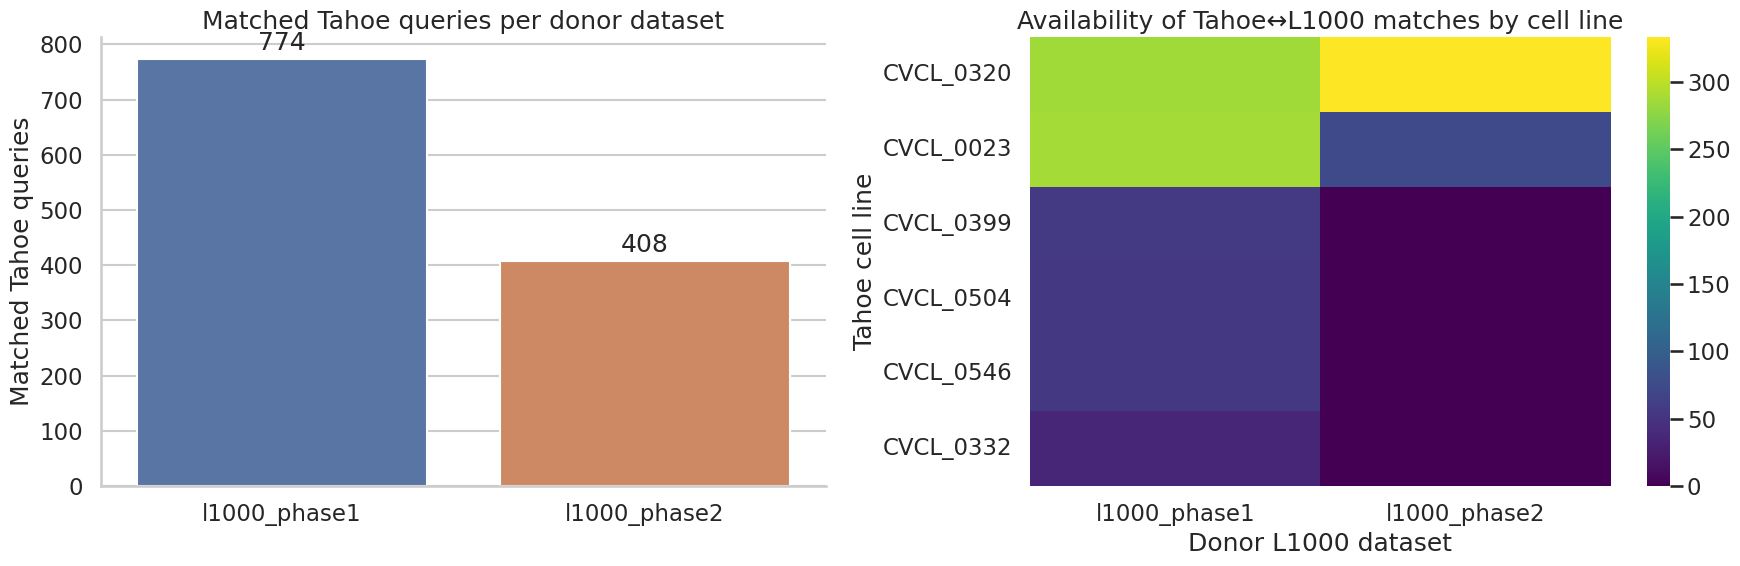

In [6]:
availability = truth_summary_df.pivot_table(
    index="query_cell_type",
    columns="db_dataset",
    values="n_truth_queries",
    fill_value=0,
)
availability = availability.loc[availability.max(axis=1).sort_values(ascending=False).index]
donor_counts = truth_df.groupby("db_dataset").size().rename("n_truth_matches").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.28 * len(availability))))
sns.barplot(data=donor_counts, x="db_dataset", y="n_truth_matches", ax=axes[0], palette="deep")
axes[0].set_title("Matched Tahoe queries per donor dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("Matched Tahoe queries")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3)

sns.heatmap(availability, cmap="viridis", ax=axes[1])
axes[1].set_title("Availability of Tahoe↔L1000 matches by cell line")
axes[1].set_xlabel("Donor L1000 dataset")
axes[1].set_ylabel("Tahoe cell line")
plt.tight_layout()


/tmp/ipykernel_349604/3239442665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=match_metrics, x="db_dataset", y="pearson_logfc", ax=axes[0], showfliers=False, palette="Set2")
/tmp/ipykernel_349604/3239442665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=match_metrics, x="db_dataset", y="topk_signed_overlap", ax=axes[1], showfliers=False, palette="Set3")


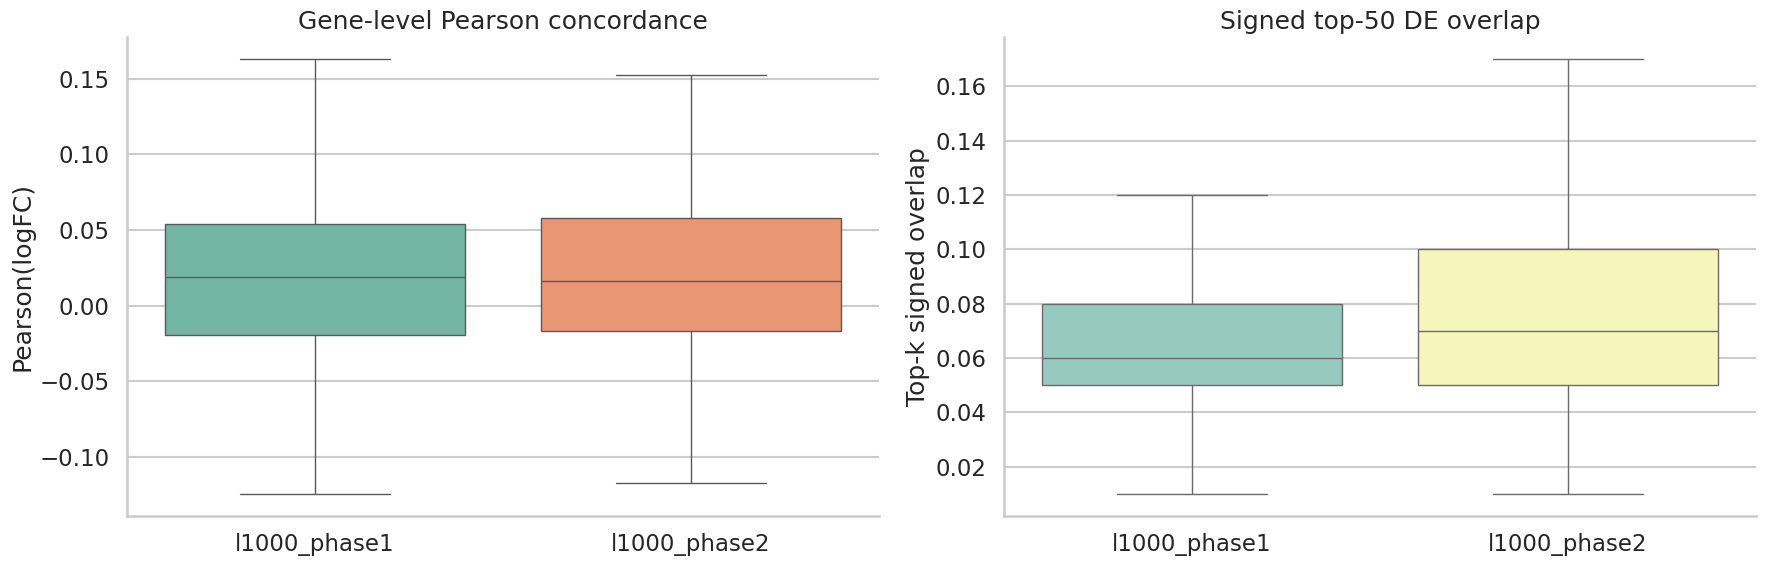

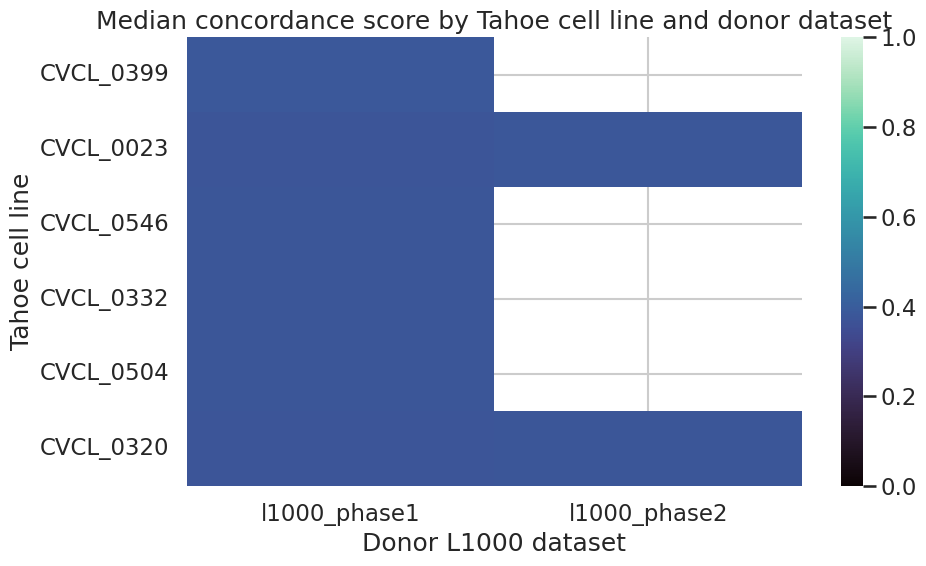

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=match_metrics, x="db_dataset", y="pearson_logfc", ax=axes[0], showfliers=False, palette="Set2")
axes[0].set_title("Gene-level Pearson concordance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Pearson(logFC)")

sns.boxplot(data=match_metrics, x="db_dataset", y="topk_signed_overlap", ax=axes[1], showfliers=False, palette="Set3")
axes[1].set_title(f"Signed top-{TOP_K} DE overlap")
axes[1].set_xlabel("")
axes[1].set_ylabel("Top-k signed overlap")
plt.tight_layout()

cell_heatmap = match_metrics.groupby(["query_cell_type", "db_dataset"])["concordance_score"].median().unstack()
cell_heatmap = cell_heatmap.loc[cell_heatmap.max(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, max(6, 0.28 * len(cell_heatmap))))
sns.heatmap(cell_heatmap, cmap="mako", vmin=0.0, vmax=1.0)
plt.title("Median concordance score by Tahoe cell line and donor dataset")
plt.xlabel("Donor L1000 dataset")
plt.ylabel("Tahoe cell line")
plt.tight_layout()


/tmp/ipykernel_349604/2262162835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_compounds, x="median_concordance", y="label", palette="crest")


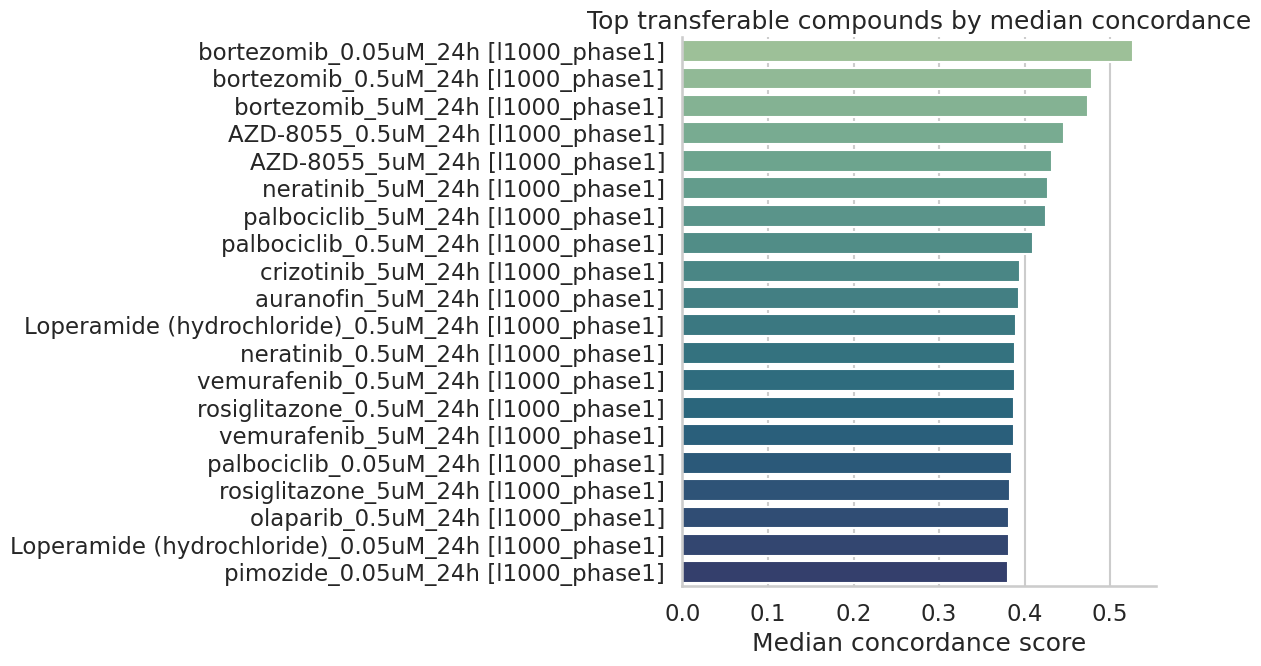

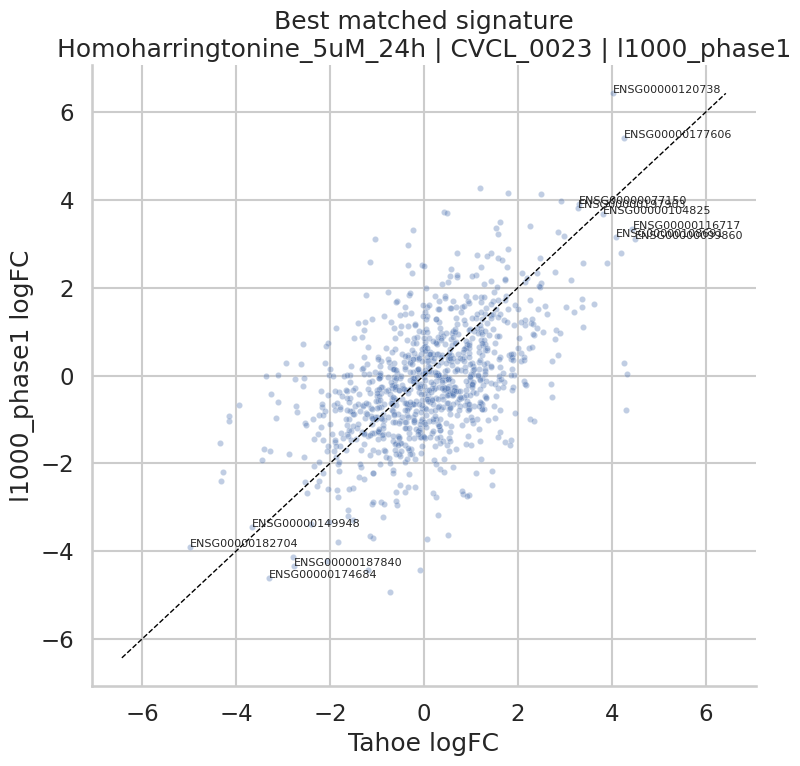

In [8]:
compound_rank = (
    match_metrics.groupby(["db_dataset", "pubchem_cid", "compound_label"], as_index=False)
    .agg(
        n_matches=("match_id", "nunique"),
        median_concordance=("concordance_score", "median"),
        median_pearson=("pearson_logfc", "median"),
    )
)
top_compounds = (
    compound_rank.loc[compound_rank["n_matches"] >= 3]
    .sort_values(["median_concordance", "n_matches"], ascending=[False, False])
    .head(20)
    .copy()
)
top_compounds["label"] = top_compounds["compound_label"] + " [" + top_compounds["db_dataset"] + "]"

plt.figure(figsize=(12, max(6, 0.35 * len(top_compounds))))
sns.barplot(data=top_compounds, x="median_concordance", y="label", palette="crest")
plt.title("Top transferable compounds by median concordance")
plt.xlabel("Median concordance score")
plt.ylabel("")
plt.tight_layout()

best_example = match_metrics.sort_values(["concordance_score", "pearson_logfc"], ascending=False).iloc[0]
pair_adata = ad.read_h5ad(best_example["pair_path"])
values = dense_layer(pair_adata, REPRESENTATION)
x = values[int(best_example["row_idx_tahoe"])]
y = values[int(best_example["row_idx_donor"])]
plot_df = pd.DataFrame(
    {
        "Tahoe logFC": x,
        f"{best_example['db_dataset']} logFC": y,
        "gene_id": pair_adata.var_names.to_numpy(dtype=str),
    }
)
top_gene_idx = np.argsort(-(np.abs(x) + np.abs(y)))[:12]
limit = float(np.nanmax(np.abs(np.concatenate([x, y]))))

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x="Tahoe logFC",
    y=f"{best_example['db_dataset']} logFC",
    s=20,
    alpha=0.35,
    ax=ax,
)
ax.plot([-limit, limit], [-limit, limit], linestyle="--", color="black", linewidth=1)
for idx in top_gene_idx:
    ax.text(x[idx], y[idx], pair_adata.var_names[idx], fontsize=8)
ax.set_title(
    f"Best matched signature\n{best_example['compound_label']} | {best_example['query_cell_type']} | {best_example['db_dataset']}"
)
plt.tight_layout()


,gene_id,n_strong_matches,n_sign_agree_when_strong,mean_abs_logfc_tahoe_when_strong,portable_score
0,ENSG00000126602,15,15,0.484001,1.000000
8,ENSG00000112701,17,15,1.459859,0.882353
9,ENSG00000127947,20,17,0.736673,0.850000
10,ENSG00000095066,33,28,0.175355,0.848485
12,ENSG00000171302,112,92,0.285276,0.821429
13,ENSG00000116171,11,9,0.144652,0.818182
14,ENSG00000079459,54,44,0.848932,0.814815
15,ENSG00000198805,83,67,0.519306,0.807229
16,ENSG00000143153,57,46,0.591201,0.807018
17,ENSG00000108669,20,16,0.427800,0.800000


/tmp/ipykernel_349604/2871287554.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=portable_top, x="portable_score", y="gene_id", palette="flare")


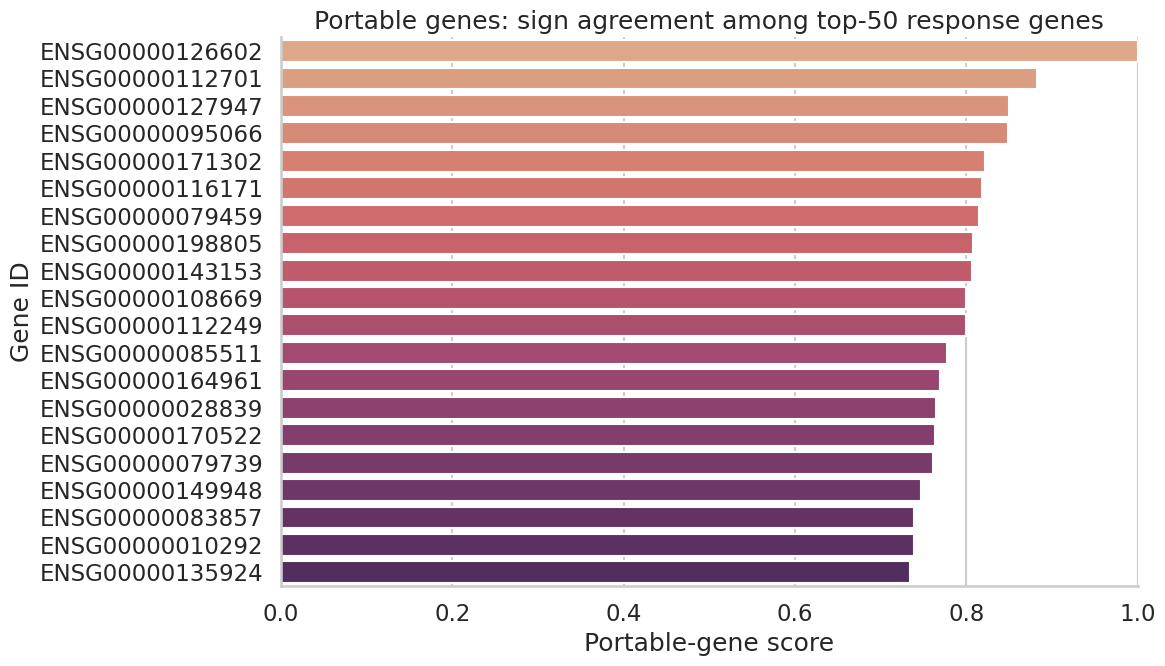

In [9]:
portable_cache = CACHE_DIR / "portable_genes.csv"
if portable_cache.exists():
    portable_genes = pd.read_csv(portable_cache)
else:
    portable_genes = compute_portable_gene_summary(pair_paths, representation=REPRESENTATION, top_k=TOP_K)
    portable_genes.to_csv(portable_cache, index=False)

portable_top = portable_genes.loc[portable_genes["n_strong_matches"] >= 10].head(20).copy()
display(portable_top)

plt.figure(figsize=(12, max(6, 0.35 * len(portable_top))))
sns.barplot(data=portable_top, x="portable_score", y="gene_id", palette="flare")
plt.title(f"Portable genes: sign agreement among top-{TOP_K} response genes")
plt.xlabel("Portable-gene score")
plt.ylabel("Gene ID")
plt.xlim(0, 1)
plt.tight_layout()


## Interpretation Notes

This notebook is deliberately a **transferability analysis**, not a predictive model. The plots are intended to answer:

- where Tahoe has enough exact matched perturbations to borrow information from L1000,
- which Tahoe cell lines appear more transferable,
- which compounds have stronger cross-dataset agreement,
- and which genes look more portable under strong responses.

That matches the tighter framing from the project note:

- use donor signatures as evidence or priors,
- do not replace Tahoe labels with donor labels,
- and prefer stable response subsets over raw whole-transcriptome transfer.

Natural next steps after this notebook are:

- train a donor gating model using the concordance features,
- and compare full-gene prediction against restricted portable-gene or pathway targets.